<a href="https://colab.research.google.com/github/awantikaAsthana/resnet/blob/main/resnet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# check GPU
import torch
print(f"GPU available: {torch.cuda.is_available()}")
print(f"Device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

GPU available: True
Device: Tesla T4


In [ ]:
%%writefile model.py

import torch
import torch.nn as nn


class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, stride, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, 1, 1, bias=False),
            nn.BatchNorm2d(out_channels)
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        return self.relu(self.block(x) + self.shortcut(x))


class ResNet(nn.Module):
    """ResNet for CIFAR-10. depth = 6n + 2"""
    def __init__(self, depth=20, num_classes=10):
        super().__init__()
        assert (depth - 2) % 6 == 0
        n = (depth - 2) // 6

        self.model = nn.Sequential(
            nn.Conv2d(3, 16, 3, 1, 1, bias=False),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),

            *[BasicBlock(16, 16) for _ in range(n)],

            BasicBlock(16, 32, stride=2),
            *[BasicBlock(32, 32) for _ in range(n - 1)],

            BasicBlock(32, 64, stride=2),
            *[BasicBlock(64, 64) for _ in range(n - 1)],

            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(64, num_classes)
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        return self.model(x)


class PlainBlock(nn.Module):
    """Same as BasicBlock but NO shortcut"""
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, stride, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, 1, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)   # NO skip connection


class PlainCNN(nn.Module):
    """Plain CNN - same structure as ResNet but no residual connections"""
    def __init__(self, depth=20, num_classes=10):
        super().__init__()
        assert (depth - 2) % 6 == 0
        n = (depth - 2) // 6

        self.model = nn.Sequential(
            nn.Conv2d(3, 16, 3, 1, 1, bias=False),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),

            *[PlainBlock(16, 16) for _ in range(n)],

            PlainBlock(16, 32, stride=2),
            *[PlainBlock(32, 32) for _ in range(n - 1)],

            PlainBlock(32, 64, stride=2),
            *[PlainBlock(64, 64) for _ in range(n - 1)],

            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(64, num_classes)
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        return self.model(x)

Writing model.py


In [ ]:
%%writefile train.py

import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as T
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt
import os
import json

from model import ResNet, PlainCNN

# ── config ─────────────────────────────────────────────────────
EPOCHS      = 164       # reduce to 30 for quick test
BATCH_SIZE  = 128
LR          = 0.1
DEVICE      = "cuda" if torch.cuda.is_available() else "cpu"


def get_loaders():
    train_transform = T.Compose([
        T.RandomCrop(32, padding=4),
        T.RandomHorizontalFlip(),
        T.ToTensor(),
        T.Normalize((0.4914, 0.4822, 0.4465),
                    (0.2023, 0.1994, 0.2010)),
    ])
    test_transform = T.Compose([
        T.ToTensor(),
        T.Normalize((0.4914, 0.4822, 0.4465),
                    (0.2023, 0.1994, 0.2010)),
    ])

    train_set = torchvision.datasets.CIFAR10(
        "./data", train=True,  download=True, transform=train_transform)
    test_set  = torchvision.datasets.CIFAR10(
        "./data", train=False, download=True, transform=test_transform)

    train_loader = DataLoader(train_set, BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
    test_loader  = DataLoader(test_set,  BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
    return train_loader, test_loader


def run_epoch(model, loader, criterion, optimizer, training):
    model.train() if training else model.eval()
    total_loss, correct, total = 0.0, 0, 0

    with torch.set_grad_enabled(training):
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss    = criterion(outputs, labels)

            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * images.size(0)
            correct    += outputs.argmax(1).eq(labels).sum().item()
            total      += images.size(0)

    return total_loss / total, 100.0 * correct / total


def train_model(model, name, train_loader, test_loader, epochs):
    print(f"\n{'='*50}")
    print(f"  Training: {name}")
    print(f"  Params  : {sum(p.numel() for p in model.parameters()):,}")
    print(f"{'='*50}")

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=LR,
                                momentum=0.9, weight_decay=1e-4, nesterov=True)

    # scale milestones if using fewer epochs
    m1 = int(0.5  * epochs)
    m2 = int(0.75 * epochs)
    scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, [m1, m2], gamma=0.1)

    history  = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_acc = 0.0
    os.makedirs("checkpoints", exist_ok=True)

    for epoch in range(epochs):
        train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer, True)
        val_loss,   val_acc   = run_epoch(model, test_loader,  criterion, None,      False)
        scheduler.step()

        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), f"checkpoints/{name}_best.pth")
            star = " ★"
        else:
            star = ""

        # print every 5 epochs
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"  Epoch {epoch+1:>3}/{epochs}  "
                  f"train {train_loss:.4f}/{train_acc:.1f}%  "
                  f"val {val_loss:.4f}/{val_acc:.1f}%{star}")

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

    print(f"\n  Best val accuracy: {best_acc:.2f}%")
    return history, best_acc


def plot_comparison(results, scores):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    colors = {
        "Plain-20":  "#FF6B6B",
        "Plain-56":  "#FF0000",
        "ResNet-20": "#4ECDC4",
        "ResNet-56": "#0000FF"
    }

    # ── Error curves ───────────────────────────────────────────
    for ax, split in zip(axes, ["train", "val"]):
        for name, hist in results.items():
            error = [100 - a for a in hist[f"{split}_acc"]]
            style = "--" if "Plain" in name else "-"
            ax.plot(error, label=name, color=colors.get(name, "gray"),
                    linestyle=style, linewidth=1.8)

        ax.set_title(f"{'Training' if split=='train' else 'Validation'} Error (%)",
                     fontsize=13, fontweight="bold")
        ax.set_xlabel("Epoch"); ax.set_ylabel("Error (%)")
        ax.legend(); ax.grid(True, alpha=0.3)

    plt.suptitle("Plain CNN vs ResNet — Degradation Problem (He et al., 2016)",
                 fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig("comparison.png", dpi=150, bbox_inches="tight")
    plt.show()

    # ── Bar chart ──────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(8, 5))
    names = list(scores.keys())
    accs  = list(scores.values())
    bar_colors = [colors.get(n, "gray") for n in names]
    bars = ax.bar(names, accs, color=bar_colors, edgecolor="black", width=0.5)

    for bar, acc in zip(bars, accs):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.2,
                f"{acc:.1f}%", ha="center", fontsize=11, fontweight="bold")

    ax.set_ylim(80, 100)
    ax.set_ylabel("Test Accuracy (%)", fontsize=12)
    ax.set_title("Final Accuracy Comparison", fontsize=13, fontweight="bold")
    ax.grid(True, alpha=0.3, axis="y")
    plt.tight_layout()
    plt.savefig("bar_chart.png", dpi=150)
    plt.show()

    print("Plots saved → comparison.png, bar_chart.png")


def print_summary(scores):
    print(f"\n{'='*55}")
    print(f"  FINAL RESULTS")
    print(f"{'='*55}")
    print(f"  {'Model':<20} {'Accuracy':>10} {'Error':>10}")
    print(f"  {'-'*42}")
    for name, acc in scores.items():
        print(f"  {name:<20} {acc:>9.2f}% {100-acc:>9.2f}%")

    print(f"\n  KEY FINDINGS:")
    plain = {n: a for n, a in scores.items() if "Plain"  in n}
    resnt = {n: a for n, a in scores.items() if "ResNet" in n}

    if "Plain-20" in plain and "Plain-56" in plain:
        diff = plain["Plain-20"] - plain["Plain-56"]
        print(f"  ✗ Plain-56 is {diff:.2f}% WORSE than Plain-20  ← degradation!")

    if "ResNet-20" in resnt and "ResNet-56" in resnt:
        diff = resnt["ResNet-56"] - resnt["ResNet-20"]
        print(f"  ✓ ResNet-56 is {diff:.2f}% BETTER than ResNet-20 ← solved!")

    for depth in ["20", "56"]:
        pn, rn = f"Plain-{depth}", f"ResNet-{depth}"
        if pn in scores and rn in scores:
            diff = scores[rn] - scores[pn]
            print(f"  ✓ ResNet-{depth} beats Plain-{depth} by {diff:.2f}%")
    print(f"{'='*55}")

Writing train.py


In [ ]:
%%writefile evaluate.py

import torch
import torchvision
import torchvision.transforms as T
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

from model import ResNet, PlainCNN

DEVICE  = "cuda" if torch.cuda.is_available() else "cpu"
CLASSES = ["airplane","automobile","bird","cat","deer",
           "dog","frog","horse","ship","truck"]


def get_test_loader():
    transform = T.Compose([
        T.ToTensor(),
        T.Normalize((0.4914, 0.4822, 0.4465),
                    (0.2023, 0.1994, 0.2010)),
    ])
    test_set = torchvision.datasets.CIFAR10(
        "./data", train=False, download=True, transform=transform)
    return DataLoader(test_set, 128, shuffle=False, num_workers=2)


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    correct, total   = 0, 0
    all_preds, all_labels = [], []

    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        preds    = model(images).argmax(1)
        correct += preds.eq(labels).sum().item()
        total   += labels.size(0)
        all_preds  += preds.cpu().tolist()
        all_labels += labels.cpu().tolist()

    return 100.0 * correct / total, all_preds, all_labels


def plot_confusion_matrix(labels, preds, title="Confusion Matrix"):
    cm = np.zeros((10, 10), dtype=int)
    for t, p in zip(labels, preds):
        cm[t][p] += 1

    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(cm, cmap="Blues")
    plt.colorbar(im)
    ax.set_xticks(range(10)); ax.set_xticklabels(CLASSES, rotation=45, ha="right")
    ax.set_yticks(range(10)); ax.set_yticklabels(CLASSES)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(title, fontsize=13, fontweight="bold")

    for i in range(10):
        for j in range(10):
            ax.text(j, i, str(cm[i,j]), ha="center", va="center",
                    color="white" if cm[i,j] > cm.max()/2 else "black", fontsize=8)

    plt.tight_layout()
    fname = title.lower().replace(" ", "_") + ".png"
    plt.savefig(fname, dpi=150)
    plt.show()
    print(f"Saved → {fname}")


def show_predictions(loader, model, n=16):
    """Show sample images with predicted vs true labels"""
    model.eval()
    images, labels = next(iter(loader))
    images_gpu = images.to(DEVICE)
    preds = model(images_gpu).argmax(1).cpu()

    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3,1,1)
    std  = torch.tensor([0.2023, 0.1994, 0.2010]).view(3,1,1)

    fig, axes = plt.subplots(2, 8, figsize=(16, 5))
    for i, ax in enumerate(axes.flat):
        if i >= n: break
        img = (images[i] * std + mean).permute(1,2,0).clamp(0,1)
        ax.imshow(img)
        correct = preds[i] == labels[i]
        color   = "green" if correct else "red"
        ax.set_title(f"P: {CLASSES[preds[i]]}\nT: {CLASSES[labels[i]]}",
                     fontsize=7, color=color)
        ax.axis("off")

    plt.suptitle("Predictions  (green=correct  red=wrong)", fontsize=12)
    plt.tight_layout()
    plt.savefig("predictions.png", dpi=150)
    plt.show()
    print("Saved → predictions.png")

Writing evaluate.py


Training for 30 epochs on cuda

  Training: Plain-20
  Params  : 269,722
  Epoch   1/30  train 1.6637/37.3%  val 1.4818/47.0% ★
  Epoch   5/30  train 0.7326/74.5%  val 0.7332/74.9% ★
  Epoch  10/30  train 0.5489/81.0%  val 0.6486/78.4% ★
  Epoch  15/30  train 0.4709/83.5%  val 0.6059/78.8%
  Epoch  20/30  train 0.3073/89.2%  val 0.3970/86.5%
  Epoch  25/30  train 0.2717/90.5%  val 0.3777/87.2%
  Epoch  30/30  train 0.2687/90.6%  val 0.3791/87.2%

  Best val accuracy: 87.24%

  Training: ResNet-20
  Params  : 272,474
  Epoch   1/30  train 1.4253/47.5%  val 1.1582/59.3% ★
  Epoch   5/30  train 0.6153/78.7%  val 0.7573/75.3% ★
  Epoch  10/30  train 0.4502/84.5%  val 0.5225/82.5% ★
  Epoch  15/30  train 0.3828/86.5%  val 0.5185/83.0% ★
  Epoch  20/30  train 0.2337/91.9%  val 0.3592/88.0%
  Epoch  25/30  train 0.2044/92.9%  val 0.3491/88.7%
  Epoch  30/30  train 0.1994/93.1%  val 0.3515/88.6%

  Best val accuracy: 88.76%

  Training: Plain-56
  Params  : 853,018
  Epoch   1/30  train 2.2430

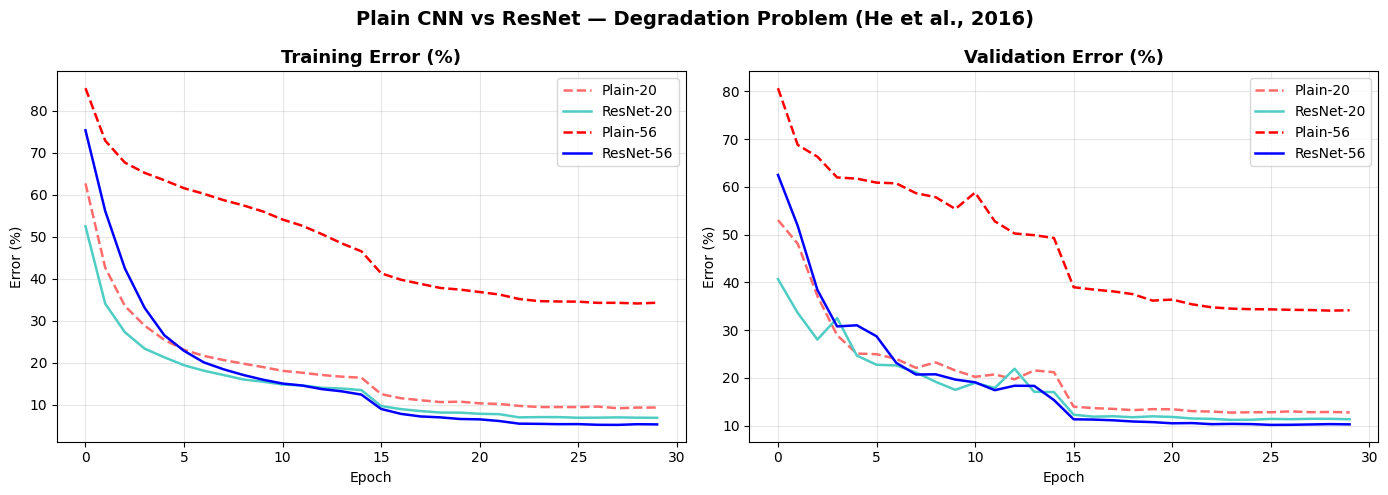

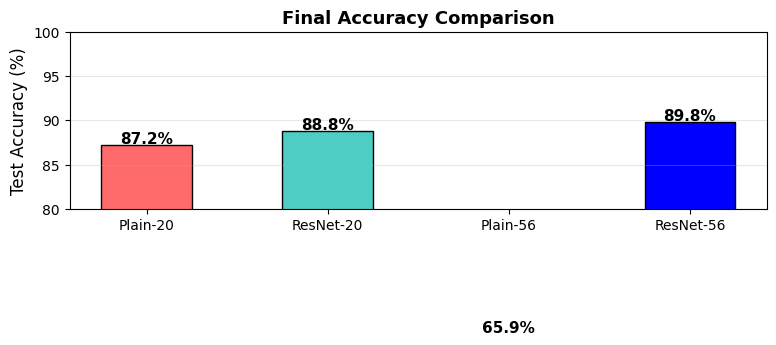

Plots saved → comparison.png, bar_chart.png

Done! Checkpoints saved in ./checkpoints/


In [ ]:
import os
import json
import torch
from train   import get_loaders, train_model, plot_comparison, print_summary
from evaluate import get_test_loader, evaluate, plot_confusion_matrix, show_predictions
from model   import ResNet, PlainCNN

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ── set epochs here ───────────────────────────────────────────
# 164 = full paper training (~45 min on Colab GPU)
# 30  = quick demo         (~8  min on Colab GPU)
EPOCHS = 30   # change to 164 for full training

print(f"Training for {EPOCHS} epochs on {DEVICE}")
print("=" * 50)

# ── load data ─────────────────────────────────────────────────
train_loader, test_loader = get_loaders()

# ── train all 4 models ────────────────────────────────────────
configs = [
    ("Plain-20",  PlainCNN(depth=20).to(DEVICE)),
    ("ResNet-20", ResNet(depth=20).to(DEVICE)),
    ("Plain-56",  PlainCNN(depth=56).to(DEVICE)),
    ("ResNet-56", ResNet(depth=56).to(DEVICE)),
]

results = {}
scores  = {}

for name, model in configs:
    hist, best = train_model(model, name, train_loader, test_loader, EPOCHS)
    results[name] = hist
    scores[name]  = best

# ── print summary ─────────────────────────────────────────────
print_summary(scores)

# ── plots ─────────────────────────────────────────────────────
plot_comparison(results, scores)

# ── save results ──────────────────────────────────────────────
with open("results.json", "w") as f:
    json.dump({"scores": scores}, f, indent=2)

print("\nDone! Checkpoints saved in ./checkpoints/")

In [ ]:
from evaluate import get_test_loader, evaluate, plot_confusion_matrix, show_predictions
from model import ResNet, PlainCNN
import torch

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
loader = get_test_loader()

models_to_eval = [
    ("Plain-20",  PlainCNN(depth=20)),
    ("ResNet-20", ResNet(depth=20)),
    ("Plain-56",  PlainCNN(depth=56)),
    ("ResNet-56", ResNet(depth=56)),
]

print(f"\n{'='*50}")
print(f"  {'Model':<20} {'Accuracy':>10} {'Error':>10}")
print(f"  {'-'*40}")

for name, model in models_to_eval:
    path = f"checkpoints/{name}_best.pth"
    if os.path.exists(path):
        model.load_state_dict(torch.load(path, map_location=DEVICE))
        model = model.to(DEVICE)
        acc, preds, labels = evaluate(model, loader)
        print(f"  {name:<20} {acc:>9.2f}% {100-acc:>9.2f}%")
    else:
        print(f"  {name:<20} checkpoint not found")

print(f"{'='*50}")

# confusion matrix for best ResNet
model = ResNet(depth=56).to(DEVICE)
model.load_state_dict(torch.load("checkpoints/ResNet-56_best.pth", map_location=DEVICE))
acc, preds, labels = evaluate(model, loader)
plot_confusion_matrix(labels, preds, "ResNet-56 Confusion Matrix")
show_predictions(loader, model)


  Model                  Accuracy      Error
  ----------------------------------------


NameError: name 'os' is not defined

In [ ]:
# run this cell to save everything to your Google Drive
from google.colab import drive
import shutil

drive.mount('/content/drive')

save_path = "/content/drive/MyDrive/ResNet_Project"
os.makedirs(save_path, exist_ok=True)

# copy checkpoints and plots
shutil.copytree("checkpoints", f"{save_path}/checkpoints", dirs_exist_ok=True)

for f in ["comparison.png", "bar_chart.png", "predictions.png",
          "ResNet-56_confusion_matrix.png", "results.json"]:
    if os.path.exists(f):
        shutil.copy(f, save_path)

print(f"Everything saved to Google Drive → {save_path}")

Mounted at /content/drive


NameError: name 'os' is not defined